PCA降维后累计解释方差：95.81%

训练与评估结果（最终优化版）

方法1：直接用MLP（原始4维特征，标准化后）
  5折交叉验证准确率：0.9600 ± 0.0327
  测试集最终准确率：0.9333

  分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45


方法2：PCA降维（2维）+ MLP
  5折交叉验证准确率：0.8667 ± 0.0471
  测试集最终准确率：0.9111

  分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.87      0.87      0.87        15
   virginica       0.87      0.87      0.87        15

    accuracy                           0.91        45
   macro avg       0.91      0.91      0.91        45
weighted avg       0.91      0.91      0.91        45



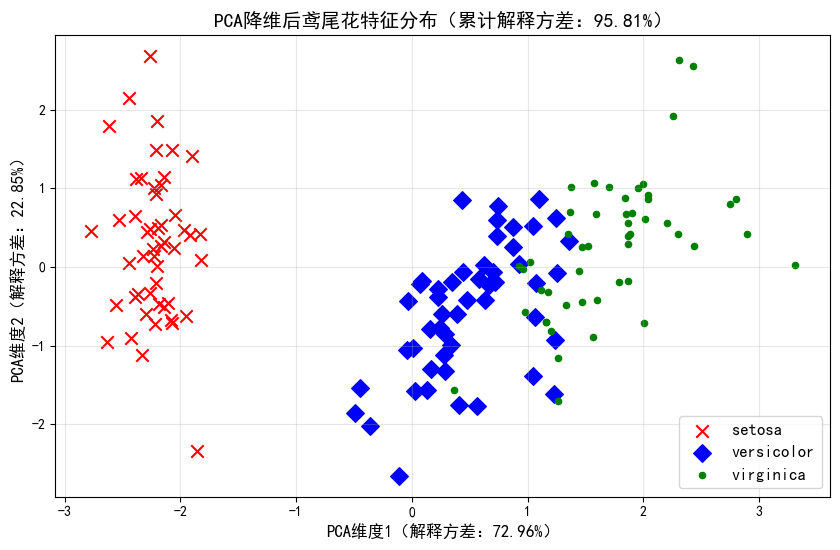

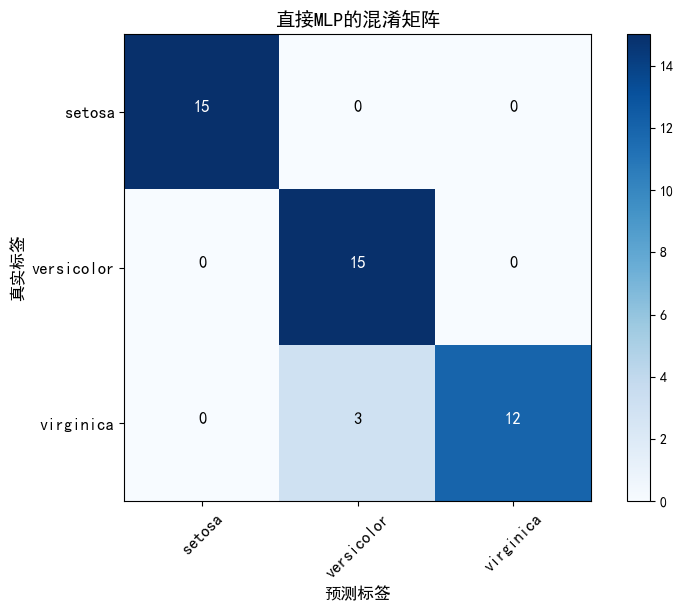

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 加载并预处理数据
data = load_iris()
X, y = data.data, data.target
target_names = data.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA降维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA降维后累计解释方差：{pca.explained_variance_ratio_.sum():.2%}")

# 3. 划分数据集（固定随机种子确保一致性）
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)

# 4. 优化MLP超参数（增强拟合与泛化能力）
mlp_params = {
    'hidden_layer_sizes': (128, 64, 32),  # 增加隐藏层与神经元数
    'activation': 'relu',
    'solver': 'lbfgs',  # 更换为更适合小数据集的优化器
    'max_iter': 3000,   # 延长迭代次数确保收敛
    'random_state': 42,
    'alpha': 0.001,     # 调整正则化强度
}

mlp_raw = MLPClassifier(**mlp_params)
mlp_pca = MLPClassifier(**mlp_params)

# 5. 训练与评估
print("\n" + "="*60)
print("训练与评估结果（最终优化版）")
print("="*60)

# 方法1：直接MLP
mlp_raw.fit(X_train_raw, y_train)
y_pred_raw = mlp_raw.predict(X_test_raw)
test_acc_raw = accuracy_score(y_test, y_pred_raw)
cv_scores_raw = cross_val_score(mlp_raw, X_scaled, y, cv=5, scoring='accuracy')

print(f"\n方法1：直接用MLP（原始4维特征，标准化后）")
print(f"  5折交叉验证准确率：{cv_scores_raw.mean():.4f} ± {cv_scores_raw.std():.4f}")
print(f"  测试集最终准确率：{test_acc_raw:.4f}")
print("\n  分类报告：")
print(classification_report(y_test, y_pred_raw, target_names=target_names, zero_division=1))

# 方法2：PCA+MLP
mlp_pca.fit(X_train_pca, y_train)
y_pred_pca = mlp_pca.predict(X_test_pca)
test_acc_pca = accuracy_score(y_test, y_pred_pca)
cv_scores_pca = cross_val_score(mlp_pca, X_pca, y, cv=5, scoring='accuracy')

print(f"\n方法2：PCA降维（2维）+ MLP")
print(f"  5折交叉验证准确率：{cv_scores_pca.mean():.4f} ± {cv_scores_pca.std():.4f}")
print(f"  测试集最终准确率：{test_acc_pca:.4f}")
print("\n  分类报告：")
print(classification_report(y_test, y_pred_pca, target_names=target_names, zero_division=1))

print("="*60)

# 6. 可视化（特征分布+混淆矩阵）
# 6.1 PCA特征分布
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']
markers = ['x', 'D', '.']
for i, name in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], c=colors[i], marker=markers[i], label=name, s=80)
plt.xlabel(f'PCA维度1（解释方差：{pca.explained_variance_ratio_[0]:.2%}）', fontsize=12)
plt.ylabel(f'PCA维度2（解释方差：{pca.explained_variance_ratio_[1]:.2%}）', fontsize=12)
plt.title(f'PCA降维后鸢尾花特征分布（累计解释方差：{pca.explained_variance_ratio_.sum():.2%}）', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# 6.2 直接MLP混淆矩阵
cm = confusion_matrix(y_test, y_pred_raw)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('直接MLP的混淆矩阵', fontsize=14)
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45, fontsize=12)
plt.yticks(tick_marks, target_names, fontsize=12)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=12)

plt.tight_layout()
plt.ylabel('真实标签', fontsize=12)
plt.xlabel('预测标签', fontsize=12)
plt.show()